<a href="https://colab.research.google.com/github/Lorenasaquicoray/Applied-Machine-Learning/blob/main/Linear%20Regression%20and%20Decision%20Tree%20Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# Lab 5: Linear Regression and Decision Trees

This lab will first guide you through implementing Linear Regression using both Gradient Descent and the Closed-Form (Normal Equation) Method.

## Part One

1. Generate some data:

In [ ]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # Single feature
Y = 4 + 3 * X + np.random.randn(100, 1) # Linear relation with noise

# Add bias term (X0 = 1 for intercept)
X_b = np.c_[np.ones((100, 1)), X] # Add column of 1s for bias term

NameError: name 'np' is not defined

2. Calculate coefficents (weights) using gradient descent:

In [ ]:
# Initialize parameters
theta_gd = np.random.randn(2, 1) # Random initial weights (beta_0, beta_1)
learning_rate = 0.1
iterations = 1000
m = len(X_b)

# Gradient Descent Loop
for i in range(iterations):
  gradients = (2/m) * X_b.T.dot(X_b.dot(theta_gd) -Y) # Compute gradient
  theta_gd -= learning_rate * gradients # Update weights

3. Calculate the coefficients (weights) using the closed form equation:

In [ ]:
theta_ne = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)
print(theta_ne)

[[4.21509616]
 [2.77011339]]


4. Compare the results by outputting the calculated weights:

In [ ]:
print("Gradient Descent Solution:")
print(f"Intercept (β0): {theta_gd[0][0]}")
print(f"Coefficient (β1): {theta_gd[1][0]}")
print("\nNormal Equation Solution:")
print(f"Intercept (β0): {theta_ne[0][0]}")
print(f"Coefficient (β1): {theta_ne[1][0]}")

Gradient Descent Solution:
Intercept (β0): 4.215096157546739
Coefficient (β1): 2.7701133864384917

Normal Equation Solution:
Intercept (β0): 4.21509615754675
Coefficient (β1): 2.7701133864384806


5. Using matplotlib, plot the following:

    a. The gradient descent fit line
  
    b. The normal equation fit line

    c. Each of the data points

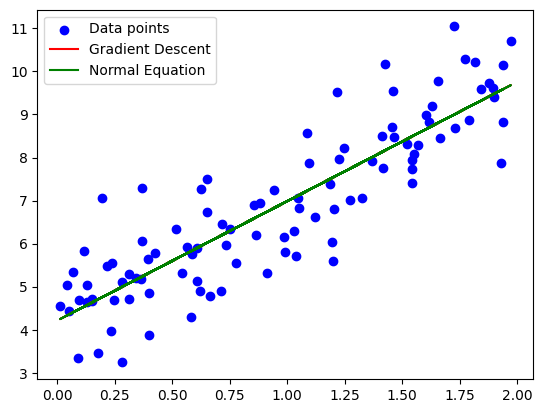

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, Y, color='blue', label='Data points')
plt.plot(X, X_b.dot(theta_gd), color='red', label='Gradient Descent')
plt.plot(X, X_b.dot(theta_ne), color='green', label='Normal Equation')
plt.legend()
plt.show()

In the output the red line (gradient descent) is not visible because the Normal equation (green line) overlaps perfectly. Meaning that the iterative model has converged to the mathematical optimal solution.

6. Repeat steps 1 through 5 but this time add one extra dimension (feature) to the data. Are you able to complete all the steps? Why or why not?

In [ ]:
np.random.seed(42)
X = 2 * np.random.rand(100, 2) # two features x1 and x2
Y = 4 + 3 * X [:,0:1] +2 * X [:,1:2] + np.random.randn(100, 1) # Linear relation with noise

# Add bias term (X0 = 1 for intercept)
X_b = np.c_[np.ones((100, 1)), X] # Add column of 1s for bias term
# Initialize parameters
theta_gd = np.random.randn(3, 1) # Random initial weights (beta_0, beta_1)
learning_rate = 0.1
iterations = 1000
m = len(X_b)

# Gradient Descent Loop
for i in range(iterations):
  gradients = (2/m) * X_b.T.dot(X_b.dot(theta_gd) -Y) # Compute gradient
  theta_gd -= learning_rate * gradients # Update weights


theta_ne = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y) #same formula
print(theta_ne)


[[3.77227226]
 [3.16933339]
 [2.17747302]]


Now we have to plot all the fitted lines but we have 3 features, leading to a 3D plot.

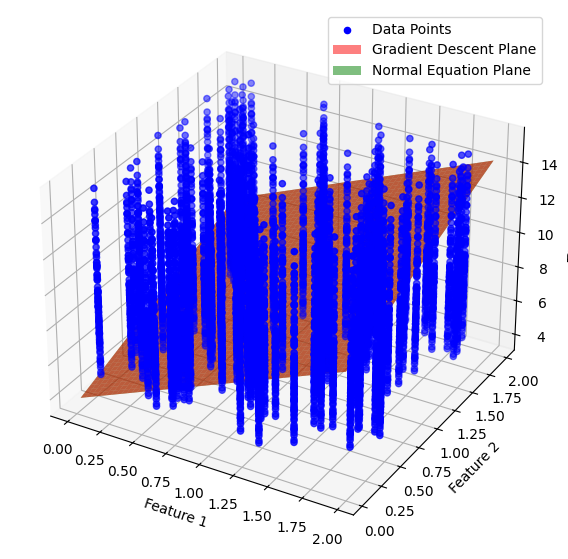

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points
ax.scatter(X[:, 0], X[:, 1], Y, color='blue', label='Data Points')

# Create a meshgrid for plotting the regression planes
x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
x2_min, x2_max = X[:, 1].min(), X[:, 1].max()
x1_surf, x2_surf = np.meshgrid(np.linspace(x1_min, x1_max, 50),
                               np.linspace(x2_min, x2_max, 50))

# Predict Y values for the Gradient Descent plane
Y_gd_surf = theta_gd[0] + theta_gd[1] * x1_surf + theta_gd[2] * x2_surf
# Predict Y values for the Normal Equation plane
Y_ne_surf = theta_ne[0] + theta_ne[1] * x1_surf + theta_ne[2] * x2_surf

# Plot the Gradient Descent plane
ax.plot_surface(x1_surf, x2_surf, Y_gd_surf, alpha=0.5, color='red', label='Gradient Descent Plane')
# Plot the Normal Equation plane
ax.plot_surface(x1_surf, x2_surf, Y_ne_surf, alpha=0.5, color='green', label='Normal Equation Plane')

# Labeling
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Target Y')
ax.legend()
plt.show()

As seen in the graph, the Gradient Descent plane and the Normal Equation plane perfectly overlap. To answer the question: yes, it is entirely possible to add an extra dimension. The mathematical logic for calculating $\theta_{ne}$ and $\theta_{gd}$ remains identical whether the dataset has 1 feature or 1,000 features. However, while visualization is still possible in this 3D case (two features plus the target), it becomes impossible to plot once you exceed three total dimensions.

7. Answer the following questions:

    a. Compare the optimized parameters from gradient descent and the normal equation, are they similar?
    Yes, they are similar. The normal equation provides the exact mathematical solution, while gradient descent is an iterative process that converges to the same solution. If the learning rate is appropriate and the algorithm runs for enough iterations, both methods will achieve very similar weights.
    
    b. Which method is faster for smaller datasets? The normal equation is faster for smaller datasets. It computes the solution directly using matrix algebra, whereas gradient descent requires multiple iterations to reach the same result.
    
    c. Which method would you use for larger datasets and why?
    For larger dataset I would use the gradient descent for larger datasets. The normal equation involves doing the inverse of a matrix that has a computational complexity of 0(n^3). Being a large dataset and having to compute this calculation one by one can be extremely slow and it will take a lot of memory. Therefore, gradient descent is more efficient and practical for large datasets.
    
    d. What happens if you set the learning rate very high?
   If the learning rate is set too high, the algorithm may overshoot the minimum point of the cost function. The error could increase with each iteration, causing the weights to diverge and potentially resulting in numerical errors (such as "not a number" values).

## Part Two

1. Create a decision tree using the method discussed in class with the following dataset:

https://www.dropbox.com/scl/fi/3sq2esty1gq1evvtedamc/simpleDataset.csv?e=1

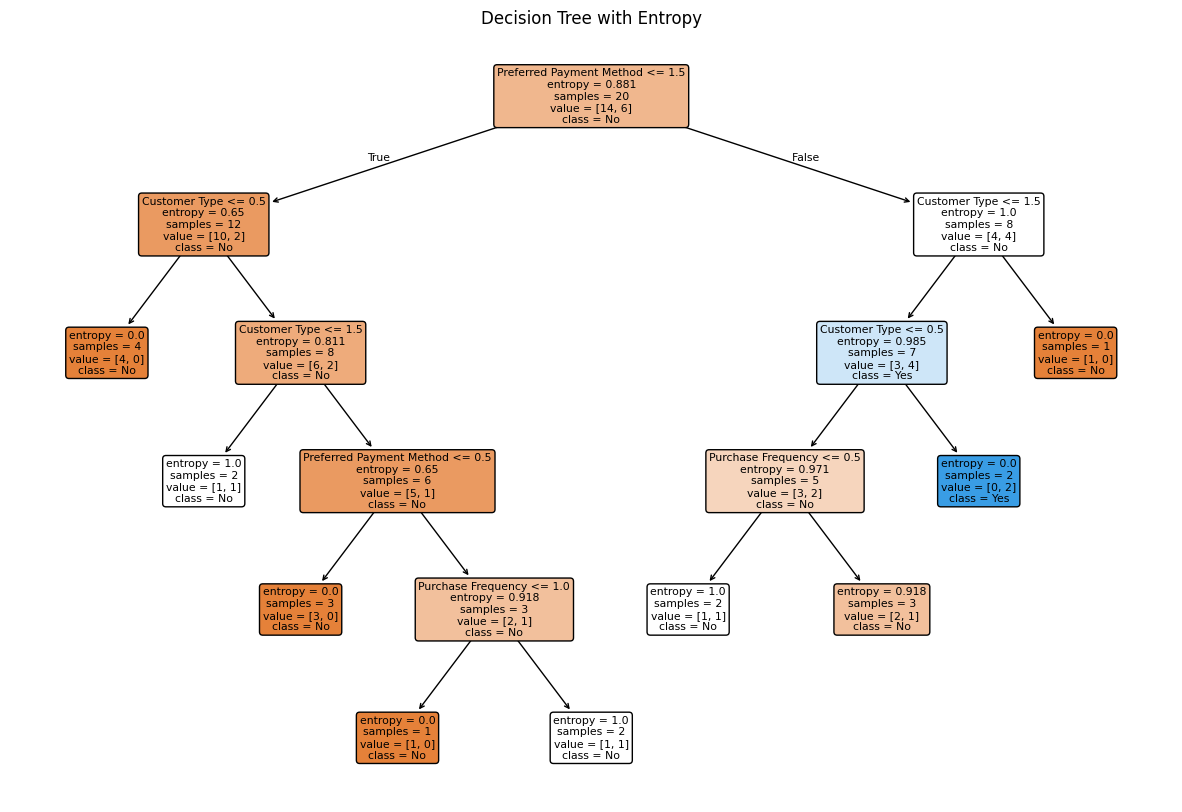

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("lab5.csv")

#enconding categorical into numerical
le = LabelEncoder()
for col in df.columns:
  df[col] = le.fit_transform(df[col])

x = df.drop('Outcome', axis = 1)
y = df['Outcome']


#we are gonna create the decision tree using entropy
dectree= DecisionTreeClassifier(criterion='entropy', random_state =42)

 #train model
dectree.fit(x,y)

#plot the tree
plt.figure(figsize=(15,10))
plot_tree(dectree,
          feature_names=x.columns.tolist(), #column names from dataframe
          class_names=['No', 'Yes'],
          filled = True,
          rounded=True)
plt.title('Decision Tree with Entropy')
plt.show()
